# Euler-Verfahren — Universelles Template
**Aufgabe:** Numerisches Lösen einer DGL 2. Ordnung mit dem Euler-Verfahren.

Jede DGL 2. Ordnung wird in ein System 1. Ordnung umgeschrieben:
$$\ddot{x}(t) = f(t,\, x,\, \dot{x})$$
$$\Rightarrow \quad v = \dot{x}, \quad \dot{v} = f(t,\, x,\, v)$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Parameter & Anfangsbedingungen — NUR HIER ANPASSEN

In [2]:
# ── Aufgaben-Parameter ────────────────────────────────────────────────────────
B  = 1.0    # Blutdruck
L0 = 0.5    # Ruhezustand

# ── Anfangsbedingungen ────────────────────────────────────────────────────────
x0    = 0.6   # x(0)
xdot0 = 0.0   # x'(0)

# ── Zeitbereich & Schrittweite ────────────────────────────────────────────────
t_start = 0.0
t_end   = 10.0
h       = 0.001

# ── Rechte Seite der DGL: x'' = f(t, x, v) ───────────────────────────────────
# Herzschlag-Modell: x''(t) = -100*(x'*x^2 - B*x' + x - L0)
def f(t, x, v):
    return -100 * (v * x**2 - B * v + x - L0)

## 2. Euler-Verfahren (allgemein, nicht anpassen)

In [3]:
def euler_2ord(f, t_start, t_end, h, x0, xdot0):
    """Euler-Verfahren für DGL 2. Ordnung x'' = f(t, x, x')."""
    t = np.arange(t_start, t_end + h, h)
    x = np.zeros(len(t))
    v = np.zeros(len(t))   # v = x'

    x[0] = x0
    v[0] = xdot0

    for i in range(len(t) - 1):
        v[i+1] = v[i] + h * f(t[i], x[i], v[i])  # x'' -> v'
        x[i+1] = x[i] + h * v[i]                  # v   -> x'

    return t, x, v

t, x, v = euler_2ord(f, t_start, t_end, h, x0, xdot0)

## 3. Plots

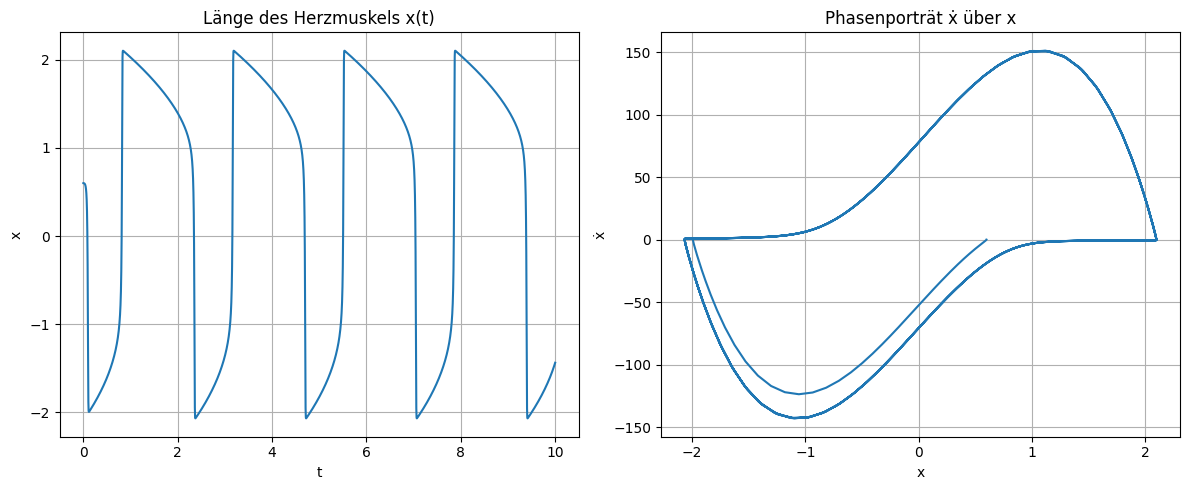

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# x(t) über die Zeit
ax1.plot(t, x)
ax1.set_xlabel('t')
ax1.set_ylabel('x')
ax1.set_title('Länge des Herzmuskels x(t)')
ax1.grid(True)

# Phasenporträt: x' über x
ax2.plot(x, v)
ax2.set_xlabel('x')
ax2.set_ylabel('ẋ')
ax2.set_title('Phasenporträt ẋ über x')
ax2.grid(True)

plt.tight_layout()
plt.show()